# Nationality Analysis: Design Diagnostics Before Outcomes

This notebook evaluates whether the planned British accused-driver comparison has usable support and statistical power. It intentionally excludes the observed sanction outcome from every diagnostic input. The results describe sample structure, not steward behavior, nationality effects, or bias.

In [1]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

from f1stewards.config import load_outcome_model_spec
from f1stewards.model_validation import (
    nationality_overlap_diagnostics,
    simulate_nationality_power,
)

ROOT = Path.cwd()
if not (ROOT / 'pyproject.toml').exists():
    ROOT = ROOT.parent
DB_PATH = ROOT / 'data' / 'processed' / 'f1_stewarding.duckdb'
SPEC = load_outcome_model_spec()
sns.set_theme(style='whitegrid', context='notebook')
COLORS = sns.color_palette('colorblind')


Could not save font_manager cache [Errno 13] Permission denied: 'C:\\Users\\Brian Zeng\\.matplotlib\\fontlist-v3.11.0.json.matplotlib-lock'


In [2]:
with duckdb.connect(str(DB_PATH), read_only=True) as connection:
    build = connection.sql(
        '''SELECT * FROM metadata.analysis_feature_builds
           ORDER BY built_at_utc DESC, feature_build_id DESC LIMIT 1'''
    ).df()
    controls = connection.sql(
        '''SELECT control_order, control, status, observed, expected, detail
           FROM analysis.feature_release_controls
           WHERE feature_build_id = (
               SELECT feature_build_id FROM metadata.analysis_feature_builds
               ORDER BY built_at_utc DESC, feature_build_id DESC LIMIT 1
           ) ORDER BY control_order'''
    ).df()
    features = connection.sql(
        '''SELECT * EXCLUDE (sanction_outcome)
           FROM analysis.v_latest_adjudication_features
           WHERE feature_label_status <> 'incomplete_human_coding'
           ORDER BY adjudication_instance_id'''
    ).df()

display(build[[
    'feature_build_id', 'workspace_id', 'release_status',
    'adjudication_rows', 'driver_role_rows'
]])
display(controls[['control', 'status', 'observed', 'expected']])


,feature_build_id,workspace_id,release_status,adjudication_rows,driver_role_rows
0,features-416a202a8006,full-coding-4b0c0d5ddd72,blocked_pending_human_review,260,503


,control,status,observed,expected
0,workspace_integrity,pass,19,19
1,document_dispositions_complete,fail,0,2002
2,adjudication_coding_complete,fail,0,1951
3,exclusion_qa_complete,fail,0,403
4,final_primary_population_nonempty,fail,0,> 0
5,final_primary_accused_identity_complete,pass,0,0
6,final_primary_binary_outcome_complete,pass,0,0
7,analytical_release,fail,one or more fail,all prerequisite controls pass


## Exposure distribution

The exposure is a sourced driver identity joined by event, session, and car number. These counts remain provisional because the accused-driver adjudication population has not yet received complete human review.

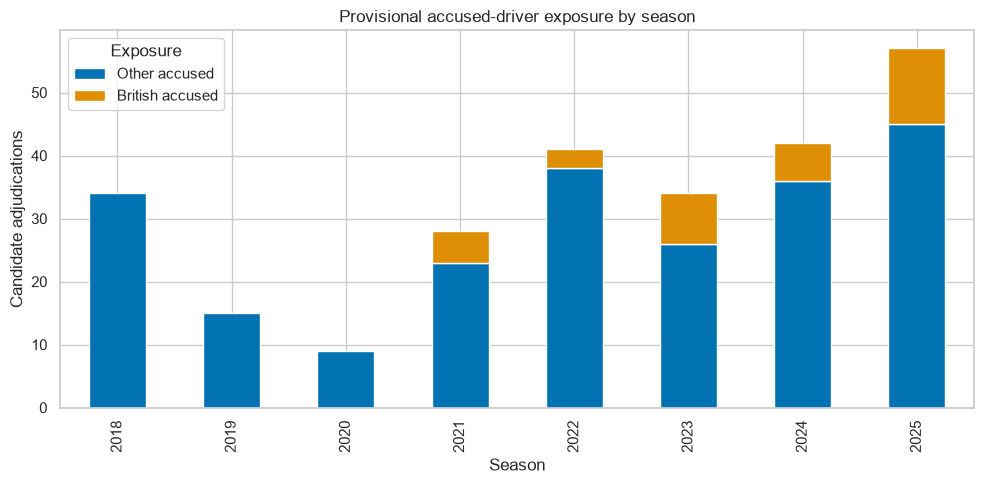

exposure,Other accused,British accused
season,,
2018,34,0
2019,15,0
2020,9,0
2021,23,5
2022,38,3
2023,26,8
2024,36,6
2025,45,12


In [3]:
season_exposure = (
    features.assign(
        exposure=np.where(
            features['british_accused_driver'].astype(bool),
            'British accused',
            'Other accused',
        )
    )
    .groupby(['season', 'exposure'])
    .size()
    .unstack(fill_value=0)
)
season_exposure = season_exposure.reindex(
    columns=['Other accused', 'British accused'], fill_value=0
)
ax = season_exposure.plot(
    kind='bar', stacked=True, figsize=(10, 5), color=[COLORS[0], COLORS[1]]
)
ax.set(title='Provisional accused-driver exposure by season', xlabel='Season', ylabel='Candidate adjudications')
ax.legend(title='Exposure', frameon=True)
plt.tight_layout()
plt.show()
display(season_exposure)


## Common support and covariate balance

The propensity model uses only the frozen pre-outcome adjustment set: incident family, season, multi-party status, and home-race status. Overlap weights are bounded; they do not manufacture support where no comparable exposure exists.

,value
rows,260
events,114
exposed_rows,34
unexposed_rows,226
exposure_prevalence,0.130769
propensity_auc,0.769261
propensity_min,0.01
propensity_max,0.871616
common_support_lower,0.058176
common_support_upper,0.365562


,dimension,level,rows,exposed_rows,unexposed_rows,exposure_prevalence,both_exposure_groups_present
6,season,2018,34,0,34,0.0,False
7,season,2019,15,0,15,0.0,False
8,season,2020,9,0,9,0.0,False


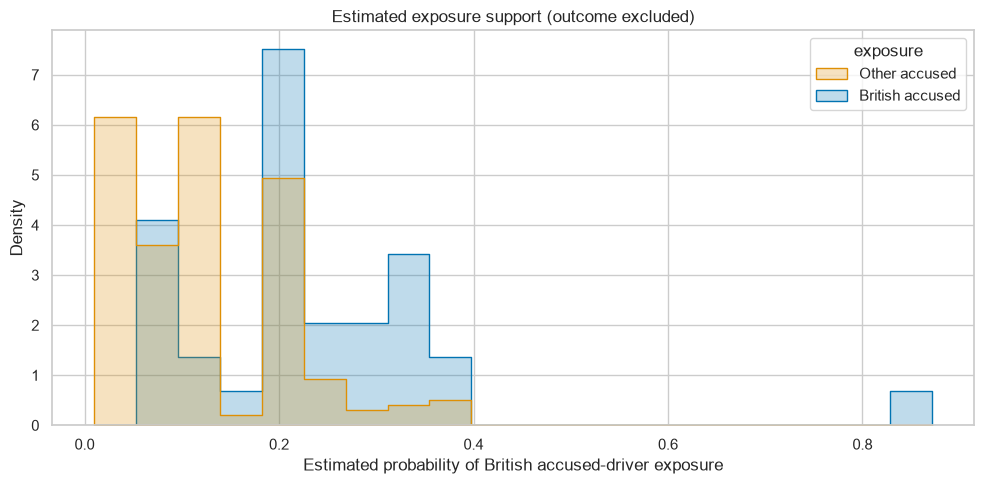

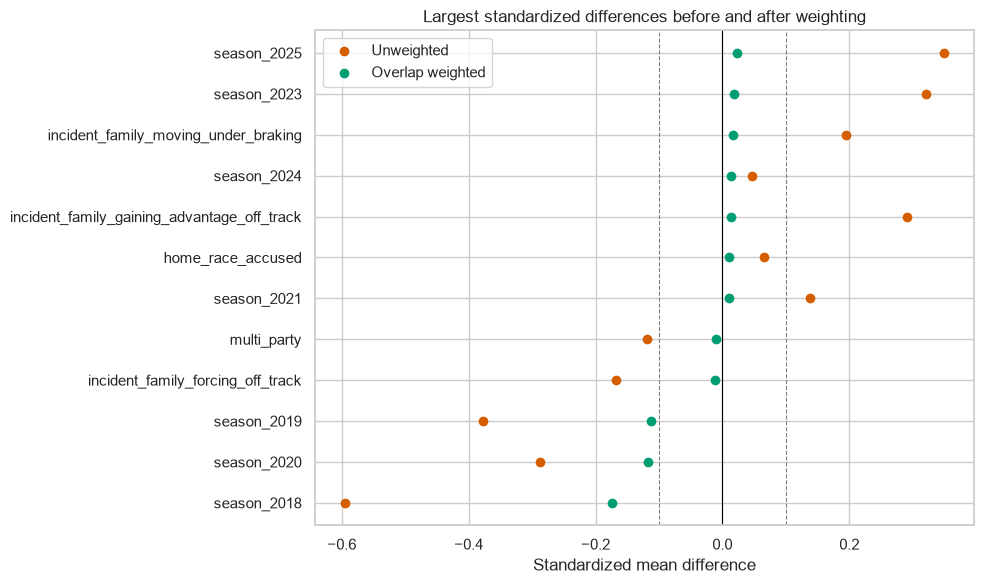

In [4]:
overlap = nationality_overlap_diagnostics(features, SPEC)
display(overlap.summary.T.rename(columns={0: 'value'}))
unsupported = overlap.support_cells.loc[
    ~overlap.support_cells['both_exposure_groups_present']
]
display(unsupported)

scores = overlap.row_scores.copy()
scores['exposure'] = np.where(
    scores['british_accused_driver'].astype(bool), 'British accused', 'Other accused'
)
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(
    data=scores, x='propensity_score_clipped', hue='exposure',
    bins=20, stat='density', common_norm=False, element='step',
    palette=[COLORS[1], COLORS[0]], ax=ax
)
ax.set(
    title='Estimated exposure support (outcome excluded)',
    xlabel='Estimated probability of British accused-driver exposure',
    ylabel='Density',
)
plt.tight_layout()
plt.show()

balance = overlap.feature_balance.head(12).sort_values('smd_overlap_weighted')
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(balance['smd_unweighted'], balance['feature'], label='Unweighted', color=COLORS[3])
ax.scatter(balance['smd_overlap_weighted'], balance['feature'], label='Overlap weighted', color=COLORS[2])
ax.axvline(0, color='black', linewidth=0.8)
ax.axvline(-0.1, color='grey', linestyle='--', linewidth=0.8)
ax.axvline(0.1, color='grey', linestyle='--', linewidth=0.8)
ax.set(title='Largest standardized differences before and after weighting', xlabel='Standardized mean difference', ylabel='')
ax.legend()
plt.tight_layout()
plt.show()


## Simulation-based power

Each scenario keeps the current exposure/covariate/event structure fixed, assumes a baseline sanction probability and target risk difference, adds an event-level random intercept, and fits a cluster-robust logistic model. No observed sanction label is loaded. The frozen target is 80% detection power with at least 90% successful fits.

,baseline_probability,target_risk_difference,target_exposure_log_odds,repetitions,successful_fits,successful_fit_fraction,simulation_fit_status,detection_power,target_power,power_target_met,monte_carlo_standard_error,median_estimated_log_odds,median_cluster_robust_se,exposed_rows,unexposed_rows,event_clusters,event_random_intercept_sd,interpretation_status
0,0.5,0.05,0.200671,500,499,0.998,stable,0.054,0.8,False,0.010108,0.229381,0.413518,34,226,114,0.35,design_simulation_not_effect_estimate
1,0.5,0.10,0.405465,500,499,0.998,stable,0.160,0.8,False,0.016395,0.414003,0.422803,34,226,114,0.35,design_simulation_not_effect_estimate
2,0.5,0.15,0.619039,500,499,0.998,stable,0.290,0.8,False,0.020293,0.592980,0.427917,34,226,114,0.35,design_simulation_not_effect_estimate
3,0.5,0.20,0.847298,500,499,0.998,stable,0.508,0.8,False,0.022358,0.867094,0.441215,34,226,114,0.35,design_simulation_not_effect_estimate
4,0.7,0.05,0.251314,500,483,0.966,stable,0.062,0.8,False,0.010785,0.298802,0.471576,34,226,114,0.35,design_simulation_not_effect_estimate
5,0.7,0.10,0.538997,500,486,0.972,stable,0.184,0.8,False,0.017329,0.624082,0.504314,34,226,114,0.35,design_simulation_not_effect_estimate
6,0.7,0.15,0.887303,500,478,0.956,stable,0.368,0.8,False,0.021567,1.001066,0.564176,34,226,114,0.35,design_simulation_not_effect_estimate
7,0.7,0.20,1.349927,500,466,0.932,stable,0.602,0.8,False,0.021890,1.410937,0.630555,34,226,114,0.35,design_simulation_not_effect_estimate


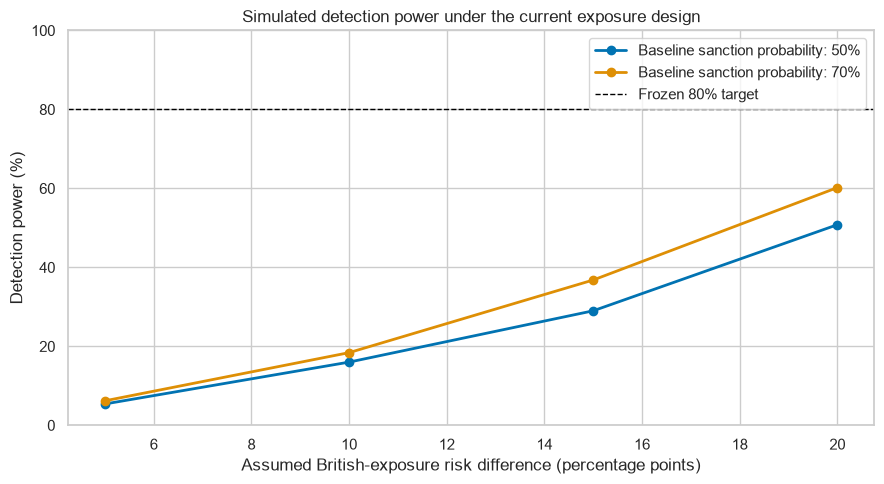

In [5]:
power = simulate_nationality_power(features, SPEC)
display(power)
fig, ax = plt.subplots(figsize=(9, 5))
for index, (baseline, group) in enumerate(power.groupby('baseline_probability')):
    ax.plot(
        group['target_risk_difference'] * 100,
        group['detection_power'] * 100,
        marker='o', linewidth=2, color=COLORS[index],
        label=f'Baseline sanction probability: {baseline:.0%}',
    )
ax.axhline(80, color='black', linestyle='--', linewidth=1, label='Frozen 80% target')
ax.set(
    title='Simulated detection power under the current exposure design',
    xlabel='Assumed British-exposure risk difference (percentage points)',
    ylabel='Detection power (%)', ylim=(0, 100),
)
ax.legend(frameon=True)
plt.tight_layout()
plt.show()


In [6]:
summary = overlap.summary.iloc[0]
max_power = power['detection_power'].max()
display(Markdown(
    f'''## Design conclusion

- The provisional population contains **{int(summary['exposed_rows'])} British** and **{int(summary['unexposed_rows'])} other** accused-driver exposures across **{int(summary['events'])} events**.
- **{summary['common_support_fraction']:.1%}** of rows fall inside the estimated common-support interval. Seasons 2018–2020 have no British accused-driver exposure in this provisional population.
- Overlap weighting reduces the largest absolute standardized difference from **{summary['max_abs_smd_unweighted']:.3f}** to **{summary['max_abs_smd_overlap_weighted']:.3f}**, leaving residual imbalance to address.
- No frozen scenario reaches 80% power; the maximum is **{max_power:.1%}**, even for a 20-point assumed difference.
- Therefore the current design cannot support a subtle nationality-effect claim. Human coding may change the population, but unless exposure and overlap improve substantially, the nationality section should remain **descriptive or inconclusive**.

**No observed sanction outcome was used, and no effect of nationality was estimated.**'''
))


## Design conclusion

- The provisional population contains **34 British** and **226 other** accused-driver exposures across **114 events**.
- **76.5%** of rows fall inside the estimated common-support interval. Seasons 2018–2020 have no British accused-driver exposure in this provisional population.
- Overlap weighting reduces the largest absolute standardized difference from **0.595** to **0.175**, leaving residual imbalance to address.
- No frozen scenario reaches 80% power; the maximum is **60.2%**, even for a 20-point assumed difference.
- Therefore the current design cannot support a subtle nationality-effect claim. Human coding may change the population, but unless exposure and overlap improve substantially, the nationality section should remain **descriptive or inconclusive**.

**No observed sanction outcome was used, and no effect of nationality was estimated.**